In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("01013500_streamflow_qc.txt", sep=r"\s+")
df.columns = ["gauge_id", "year", "month", "day", "flow", "flag"]
df['date']  = pd.to_datetime(df[['year', 'month', 'day']])
df = df.dropna()
annual_flow = df.groupby('year')['flow'].mean()

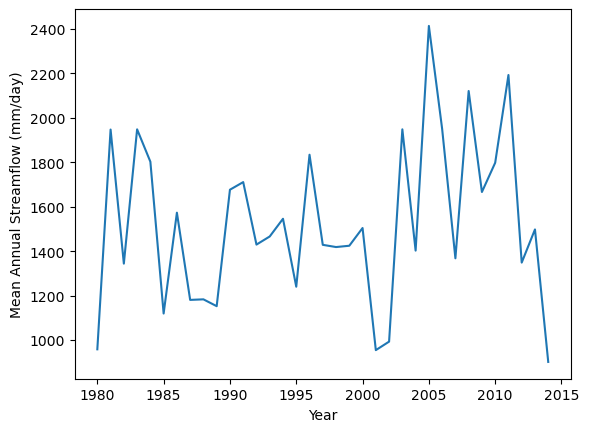

In [25]:
plt.plot(annual_flow.index, annual_flow.values)
plt.xlabel("Year")
plt.ylabel("Mean Annual Streamflow (mm/day)")

plt.savefig("figure1.png", dpi=300)

plt.show()

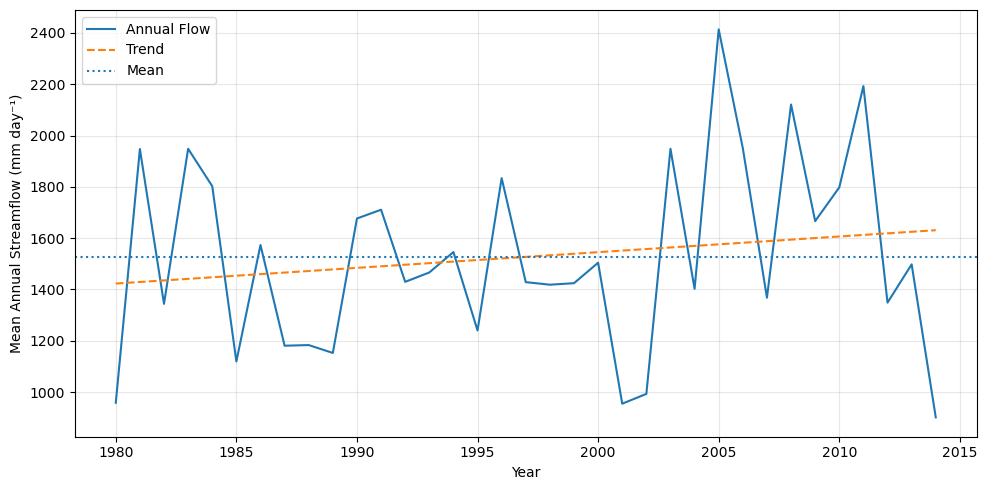

In [31]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(annual_flow.index, annual_flow.values, label="Annual Flow")

z = np.polyfit(annual_flow.index, annual_flow.values, 1)
p = np.poly1d(z)
plt.plot(annual_flow.index, p(annual_flow.index), linestyle="--", label="Trend")

mean_flow = annual_flow.mean()
plt.axhline(mean_flow, linestyle=":", label="Mean")

plt.xlabel("Year")
plt.ylabel("Mean Annual Streamflow (mm day⁻¹)")

plt.legend(loc = "upper left")
plt.grid(alpha = 0.3)

plt.tight_layout()
plt.savefig("figure1_streamflow_improved.png", dpi=300)
plt.show()

In [ ]:
!git push origin main